# Thinking in arrays

We'll double the same values with a Python loop and with one NumPy array operation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
arr = np.random.randint(0, 10, size=5)
arr

array([1, 9, 5, 1, 9])

In [3]:
double = np.zeros(5, dtype=int)
double

array([0, 0, 0, 0, 0])

In [4]:
%%timeit -r 3
for i in range(5):
    double[i] = arr[i] + arr[i]

937 ns ± 3.96 ns per loop (mean ± std. dev. of 3 runs, 1,000,000 loops each)


In [5]:
%%timeit -r 3
arr + arr

282 ns ± 10.7 ns per loop (mean ± std. dev. of 3 runs, 1,000,000 loops each)


# Replace our custom code with PyTorch

Now we'll replace our custom gradient and update code with built-in PyTorch functions. First, autograd computes the gradients, so we don't have to derive them by hand. Then an optimizer updates the coefficients.

In [6]:
import torch
import math

torch.manual_seed(42)

In [7]:
device = torch.device("cpu")
dtype = torch.float

In [8]:
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)
x, y

(tensor([-3.1416, -3.1384, -3.1353,  ...,  3.1353,  3.1384,  3.1416]),
 tensor([ 8.7423e-08, -3.1430e-03, -6.2863e-03,  ...,  6.2863e-03,
          3.1430e-03, -8.7423e-08]))

In [9]:
def initialize_weights():
    a = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    b = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    c = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    d = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    return a, b, c, d

In [10]:
wa, wb, wc, wd = initialize_weights()
wa, wb, wc, wd

(tensor(0.3367, requires_grad=True),
 tensor(0.1288, requires_grad=True),
 tensor(0.2345, requires_grad=True),
 tensor(0.2303, requires_grad=True))

In [11]:
a, b, c, d = (
    w.detach().clone().requires_grad_()
    for w in (wa, wb, wc, wd)
)
lr = 1e-6
for t in range(2000):
    y_pred = a + b * x + c * x** 2 + d * x **3
    loss = (y_pred - y).pow(2).sum()

    if t == 0:
        initial_loss = loss.item()

    if t % 100 == 0:
        print(t, loss.item())

    loss.backward()

    with torch.no_grad():
        a -= lr * a.grad
        b -= lr * b.grad
        c -= lr * c.grad
        d -= lr * d.grad

        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(a.item(), b.item(), c.item(), d.item())

0 17376.455078125
100 461.9692077636719
200 310.8812561035156
300 210.26773071289062
400 143.23683166503906
500 98.55887603759766
600 68.76502990722656
700 48.886714935302734
800 35.616764068603516
900 26.753145217895508
1000 20.829376220703125
1100 16.867849349975586
1200 14.216791152954102
1300 12.441530227661133
1400 11.251887321472168
1500 10.454093933105469
1600 9.918689727783203
1700 9.559059143066406
1800 9.31729507446289
1900 9.154642105102539
0.009059897623956203 0.8446162343025208 -0.0015629850095137954 -0.0916057676076889


In [12]:
a, b, c, d = (
    w.detach().clone().requires_grad_()
    for w in (wa, wb, wc, wd)
)
lr = 1e-6
optimizer = torch.optim.SGD([a, b, c, d], lr=lr)

for t in range(2000):
    y_pred = a + b * x + c * x** 2 + d * x **3
    loss = (y_pred - y).pow(2).sum()

    if t % 100 == 0:
        print(t, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(a.item(), b.item(), c.item(), d.item())

0 17376.455078125
100 461.9692077636719
200 310.8812561035156
300 210.26773071289062
400 143.23683166503906
500 98.55887603759766
600 68.76502990722656
700 48.886714935302734
800 35.616764068603516
900 26.75314712524414
1000 20.82938003540039
1100 16.86785125732422
1200 14.216793060302734
1300 12.441530227661133
1400 11.251887321472168
1500 10.454093933105469
1600 9.918689727783203
1700 9.559059143066406
1800 9.317296028137207
1900 9.154642105102539
0.009059898555278778 0.8446162343025208 -0.0015629850095137954 -0.0916057676076889


# Fit sine with a neural network

So far, we chose the polynomial features ourselves. Now we'll give each x to a small neural network and let it learn a nonlinear fit.

In [13]:
class TinyNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(in_features=1, out_features=10)
        self.linear2 = torch.nn.Linear(in_features=10, out_features=1)
        self.linear_relu = torch.nn.Sequential(
            self.linear1,
            torch.nn.ReLU(),
            self.linear2
        )

    def forward(self, x):
        return self.linear_relu(x)

In [14]:
model = TinyNN()

In [15]:
model.parameters()

<generator object Module.parameters at 0x11eab10e0>

In [16]:
total_params = sum([p.numel() for p in model.parameters()])
trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
total_params, trainable_params

(31, 31)

In [17]:
x.shape, y.shape

(torch.Size([2000]), torch.Size([2000]))

In [18]:
model(x[:, None]).shape

torch.Size([2000, 1])

In [19]:
lr = 1e-3
loss_fn = torch.nn.MSELoss()

model = TinyNN()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
snapshots = {}
checkpoints = {0, 10, 50, 200, 700, 1999}

model.train()
for t in range(2000):
    y_pred = model(x[:, None])
    loss = loss_fn(y_pred, y[:, None])

    if t % 100 == 0:
        print(t, loss.item())

    if t in checkpoints:
        snapshots[t] = y_pred.detach().cpu().squeeze(-1).numpy().copy()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(model.parameters())

0 0.6263493895530701
100 0.24304905533790588
200 0.20639894902706146
300 0.1956658810377121
400 0.18921853601932526
500 0.1847216635942459
600 0.18138690292835236
700 0.17876437306404114
800 0.1765812337398529
900 0.17467238008975983
1000 0.17293868958950043
1100 0.1713210493326187


1200 0.16978400945663452
1300 0.16830670833587646
1400 0.16687701642513275
1500 0.16548822820186615
1600 0.1641373336315155
1700 0.16282394528388977
1800 0.1615494191646576
1900 0.1603166162967682
<generator object Module.parameters at 0x11eab19a0>


## Watch the fit change

We'll save predictions at a few steps and plot how the network's fit changes. Step 0 shows its predictions before the first update.

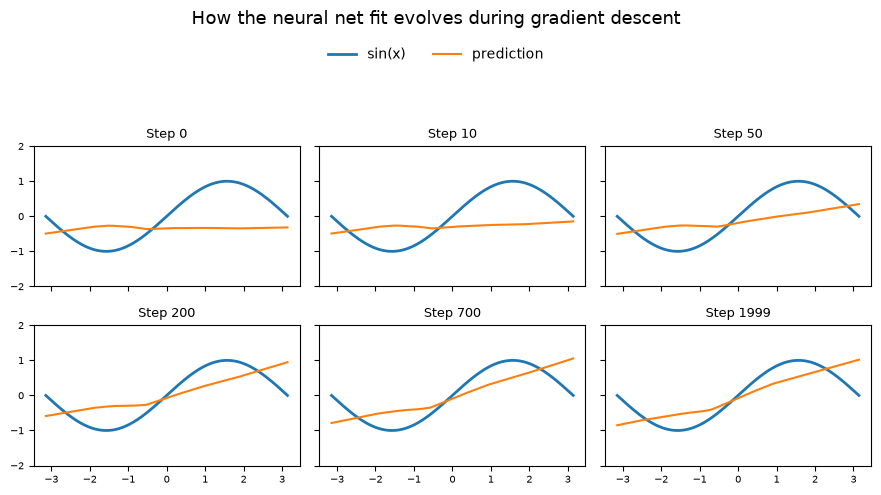

In [20]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(9, 5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (t, y_pred_snapshot) in zip(axes, snapshots.items()):
    ax.plot(x, y, label="sin(x)", linewidth=2)
    ax.plot(x, y_pred_snapshot, label="prediction")

    ax.set_title(f"Step {t}", fontsize=9)
    ax.set_ylim(-2, 2)
    ax.tick_params(labelsize=7)

# Main title
fig.suptitle(
    "How the neural net fit evolves during gradient descent",
    fontsize=13,
    y=0.98
)

# Shared legend below title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=2,
    frameon=False
)

# Leave space at top for title + legend
plt.tight_layout(rect=[0, 0, 1, 0.84])

plt.show()